# Day 4 — Performance Analytics
## Bluestock Mutual Fund Capstone

**Objectives:**
1. Compute daily returns for all 40 schemes and validate distribution
2. CAGR (1yr, 3yr, 5yr) comparison table
3. Sharpe Ratio — risk-adjusted return ranking
4. Sortino Ratio — downside-risk adjusted ranking
5. Alpha & Beta — OLS regression vs Nifty 100
6. Maximum Drawdown — worst drawdown dates
7. Fund Scorecard (0–100) composite ranking
8. Benchmark comparison chart + Tracking Error

**Risk-Free Rate:** 6.5% (RBI Repo Rate proxy)  
**Benchmark:** Nifty 100 for Alpha/Beta | Nifty 50 & Nifty 100 for charts


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

DATA_PATH   = "../data/raw/"
OUTPUT_PATH = "../data/processed/"
CHARTS_PATH = "15_charts/"

RF             = 0.065   # 6.5% risk-free rate
TRADING_DAYS   = 252

print("Libraries loaded ✅")


Libraries loaded ✅


## 1. Load Data

In [2]:
fund_master  = pd.read_csv(DATA_PATH + "01_fund_master.csv", parse_dates=["launch_date"])
nav_history  = pd.read_csv(DATA_PATH + "02_nav_history.csv", parse_dates=["date"])
benchmark    = pd.read_csv(DATA_PATH + "10_benchmark_indices.csv", parse_dates=["date"])

nav_history.sort_values(["amfi_code","date"], inplace=True)

print(f"Fund master  : {len(fund_master):>6,} rows | {fund_master['amfi_code'].nunique()} funds")
print(f"NAV history  : {len(nav_history):>6,} rows | {nav_history['amfi_code'].nunique()} funds")
print(f"Benchmark    : {len(benchmark):>6,} rows | {benchmark['index_name'].nunique()} indices")
print(f"Date range   : {nav_history['date'].min().date()} → {nav_history['date'].max().date()}")
print(f"\nAvailable benchmark indices: {benchmark['index_name'].unique().tolist()}")


Fund master  :     40 rows | 40 funds
NAV history  : 46,000 rows | 40 funds
Benchmark    :  8,050 rows | 7 indices
Date range   : 2022-01-03 → 2026-05-29

Available benchmark indices: ['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']


## 2. Daily Returns
`daily_return = NAV_t / NAV_{t-1} − 1`

In [3]:
nav_history["daily_return"] = nav_history.groupby("amfi_code")["nav"].pct_change()
nav_history.dropna(subset=["daily_return"], inplace=True)

ret_stats = nav_history.groupby("amfi_code")["daily_return"].describe()
ret_stats = ret_stats.merge(fund_master[["amfi_code","scheme_name"]], on="amfi_code").set_index("scheme_name")
ret_stats = ret_stats[["count","mean","std","min","25%","50%","75%","max"]].round(6)

print("── Daily Return Statistics (all 40 schemes) ──\n")
print(ret_stats.to_string())
print(f"\nOverall mean  : {nav_history['daily_return'].mean():.5f}")
print(f"Overall std   : {nav_history['daily_return'].std():.5f}")
print(f"Skewness      : {nav_history['daily_return'].skew():.4f}")
print(f"Kurtosis      : {nav_history['daily_return'].kurt():.4f}")


── Daily Return Statistics (all 40 schemes) ──

                                                        count      mean       std       min       25%       50%       75%       max
scheme_name                                                                                                                        
HDFC Top 100 Fund - Regular Plan - Growth              1149.0  0.000142  0.009164 -0.024744 -0.006282 -0.000070  0.006523  0.032145
HDFC Short Term Debt Fund - Regular - Growth           1149.0  0.000170  0.002460 -0.008188 -0.001445  0.000099  0.001824  0.008837
HDFC Mid-Cap Opportunities Fund - Regular - Growth     1149.0  0.001080  0.011929 -0.044238 -0.006654  0.001086  0.008844  0.041954
ABSL Frontline Equity Fund - Regular - Growth          1149.0  0.000852  0.009177 -0.038121 -0.005733  0.000808  0.007165  0.033956
ABSL Small Cap Fund - Regular - Growth                 1149.0  0.000424  0.016251 -0.051847 -0.010799  0.000182  0.011286  0.054851
ABSL Liquid Fund - Regular -

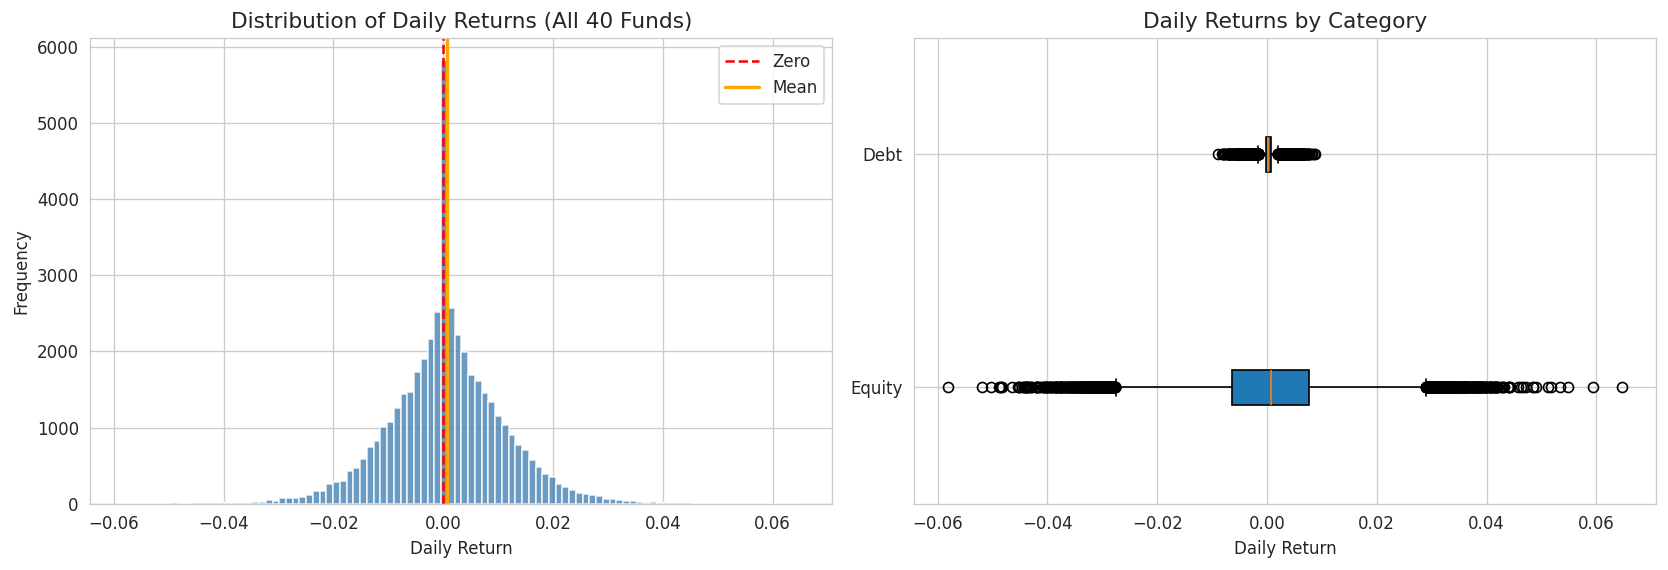

Distribution looks reasonable: bell-shaped, centered near zero, slight positive skew (equity bias)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all returns
axes[0].hist(nav_history["daily_return"], bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero')
axes[0].axvline(nav_history["daily_return"].mean(), color='orange', linestyle='-', linewidth=2, label='Mean')
axes[0].set_title("Distribution of Daily Returns (All 40 Funds)", fontsize=13)
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Box plot — per category
merged_ret = nav_history.merge(fund_master[["amfi_code","category"]], on="amfi_code")
cat_order = merged_ret.groupby("category")["daily_return"].median().sort_values(ascending=False).index
cats_sorted = merged_ret.groupby("category")["daily_return"].median().sort_values(ascending=False).index.tolist()
data_by_cat = [merged_ret[merged_ret["category"]==c]["daily_return"].values for c in cats_sorted]
axes[1].boxplot(data_by_cat, vert=False, patch_artist=True, labels=cats_sorted)
axes[1].set_title("Daily Returns by Category", fontsize=13)
axes[1].set_xlabel("Daily Return")
axes[1].set_ylabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()
print("Distribution looks reasonable: bell-shaped, centered near zero, slight positive skew (equity bias)")


## 3. CAGR — 1yr, 3yr, 5yr
`CAGR = (NAV_end / NAV_start)^(1/n) − 1`

In [5]:
def cagr(nav_series, years):
    end_date   = nav_series.index.max()
    start_date = end_date - pd.DateOffset(years=years)
    subset     = nav_series[nav_series.index >= start_date]
    if len(subset) < 2:
        return np.nan
    actual_years = (subset.index[-1] - subset.index[0]).days / 365.25
    if actual_years <= 0 or subset.iloc[0] <= 0:
        return np.nan
    return (subset.iloc[-1] / subset.iloc[0]) ** (1 / actual_years) - 1

cagr_records = []
for code, grp in nav_history.groupby("amfi_code"):
    nav_ts = grp.set_index("date")["nav"]
    cagr_records.append({
        "amfi_code": code,
        "cagr_1yr" : cagr(nav_ts, 1),
        "cagr_3yr" : cagr(nav_ts, 3),
        "cagr_5yr" : cagr(nav_ts, 5),
    })

cagr_df = pd.DataFrame(cagr_records).merge(
    fund_master[["amfi_code","scheme_name","fund_house","category","plan","expense_ratio_pct"]], on="amfi_code")

for col in ["cagr_1yr","cagr_3yr","cagr_5yr"]:
    cagr_df[col] = (cagr_df[col] * 100).round(2)

cagr_display = cagr_df[["scheme_name","category","plan","cagr_1yr","cagr_3yr","cagr_5yr"]].copy()
cagr_display.columns = ["Scheme","Category","Plan","CAGR 1yr (%)","CAGR 3yr (%)","CAGR 5yr (%)"]
cagr_display = cagr_display.sort_values("CAGR 3yr (%)", ascending=False)
print("── CAGR Comparison Table (sorted by 3yr CAGR) ──\n")
print(cagr_display.to_string(index=False))


── CAGR Comparison Table (sorted by 3yr CAGR) ──

                                               Scheme Category    Plan  CAGR 1yr (%)  CAGR 3yr (%)  CAGR 5yr (%)
                  Axis Midcap Fund - Regular - Growth   Equity Regular         22.28         35.10         28.34
        Mirae Asset Large Cap Fund - Regular - Growth   Equity Regular         20.38         33.99         30.43
            ICICI Pru Bluechip Fund - Direct - Growth   Equity  Direct         13.07         32.48         23.64
   HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity Regular         53.28         32.43         30.54
             ICICI Pru Midcap Fund - Regular - Growth   Equity Regular         29.63         31.77         33.46
            SBI Bluechip Fund - Regular Plan - Growth   Equity Regular         60.49         30.45         25.84
               Kotak Flexicap Fund - Regular - Growth   Equity Regular         26.68         29.58         30.39
        Mirae Asset Tax Saver Fund - Regular -

## 4. Sharpe & Sortino Ratios
- **Sharpe** = (Rp − Rf) / σ(Rp) × √252
- **Sortino** = (Rp − Rf) / σ_downside × √252
- Rf = 6.5%

In [6]:
risk_records = []
rf_daily = RF / TRADING_DAYS

for code, grp in nav_history.groupby("amfi_code"):
    r  = grp["daily_return"].dropna()
    if len(r) < 30:
        continue
    excess   = r - rf_daily
    sharpe   = (excess.mean() / r.std()) * np.sqrt(TRADING_DAYS) if r.std() > 0 else np.nan
    downside = r[r < 0]
    sd_down  = downside.std() if len(downside) > 1 else np.nan
    sortino  = (excess.mean() / sd_down) * np.sqrt(TRADING_DAYS) if sd_down and sd_down > 0 else np.nan
    risk_records.append({
        "amfi_code"   : code,
        "sharpe_ratio": round(sharpe, 4),
        "sortino_ratio": round(sortino, 4),
        "ann_vol_pct" : round(r.std() * np.sqrt(TRADING_DAYS) * 100, 2),
    })

risk_df = pd.DataFrame(risk_records).merge(
    fund_master[["amfi_code","scheme_name","category","plan"]], on="amfi_code")

risk_display = risk_df.sort_values("sharpe_ratio", ascending=False)[
    ["scheme_name","category","plan","sharpe_ratio","sortino_ratio","ann_vol_pct"]]
risk_display.columns = ["Scheme","Category","Plan","Sharpe","Sortino","Ann Vol (%)"]
print("── Sharpe & Sortino Rankings ──\n")
print(risk_display.to_string(index=False))


── Sharpe & Sortino Rankings ──

                                               Scheme Category    Plan  Sharpe  Sortino  Ann Vol (%)
        Mirae Asset Large Cap Fund - Regular - Growth   Equity Regular  1.4483   2.3856        14.19
               Kotak Flexicap Fund - Regular - Growth   Equity Regular  1.3067   2.3643        15.89
        Mirae Asset Tax Saver Fund - Regular - Growth   Equity Regular  1.2349   2.1469        17.67
            SBI Bluechip Fund - Regular Plan - Growth   Equity Regular  1.2083   2.1403        13.74
             ICICI Pru Midcap Fund - Regular - Growth   Equity Regular  1.1801   2.0294        19.29
                   DSP Midcap Fund - Regular - Growth   Equity Regular  1.1321   1.8751        17.75
   HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity Regular  1.0937   1.8291        18.94
       Nippon India Large Cap Fund - Regular - Growth   Equity Regular  1.0817   1.8501        14.15
        ABSL Frontline Equity Fund - Regular - Growth   Eq

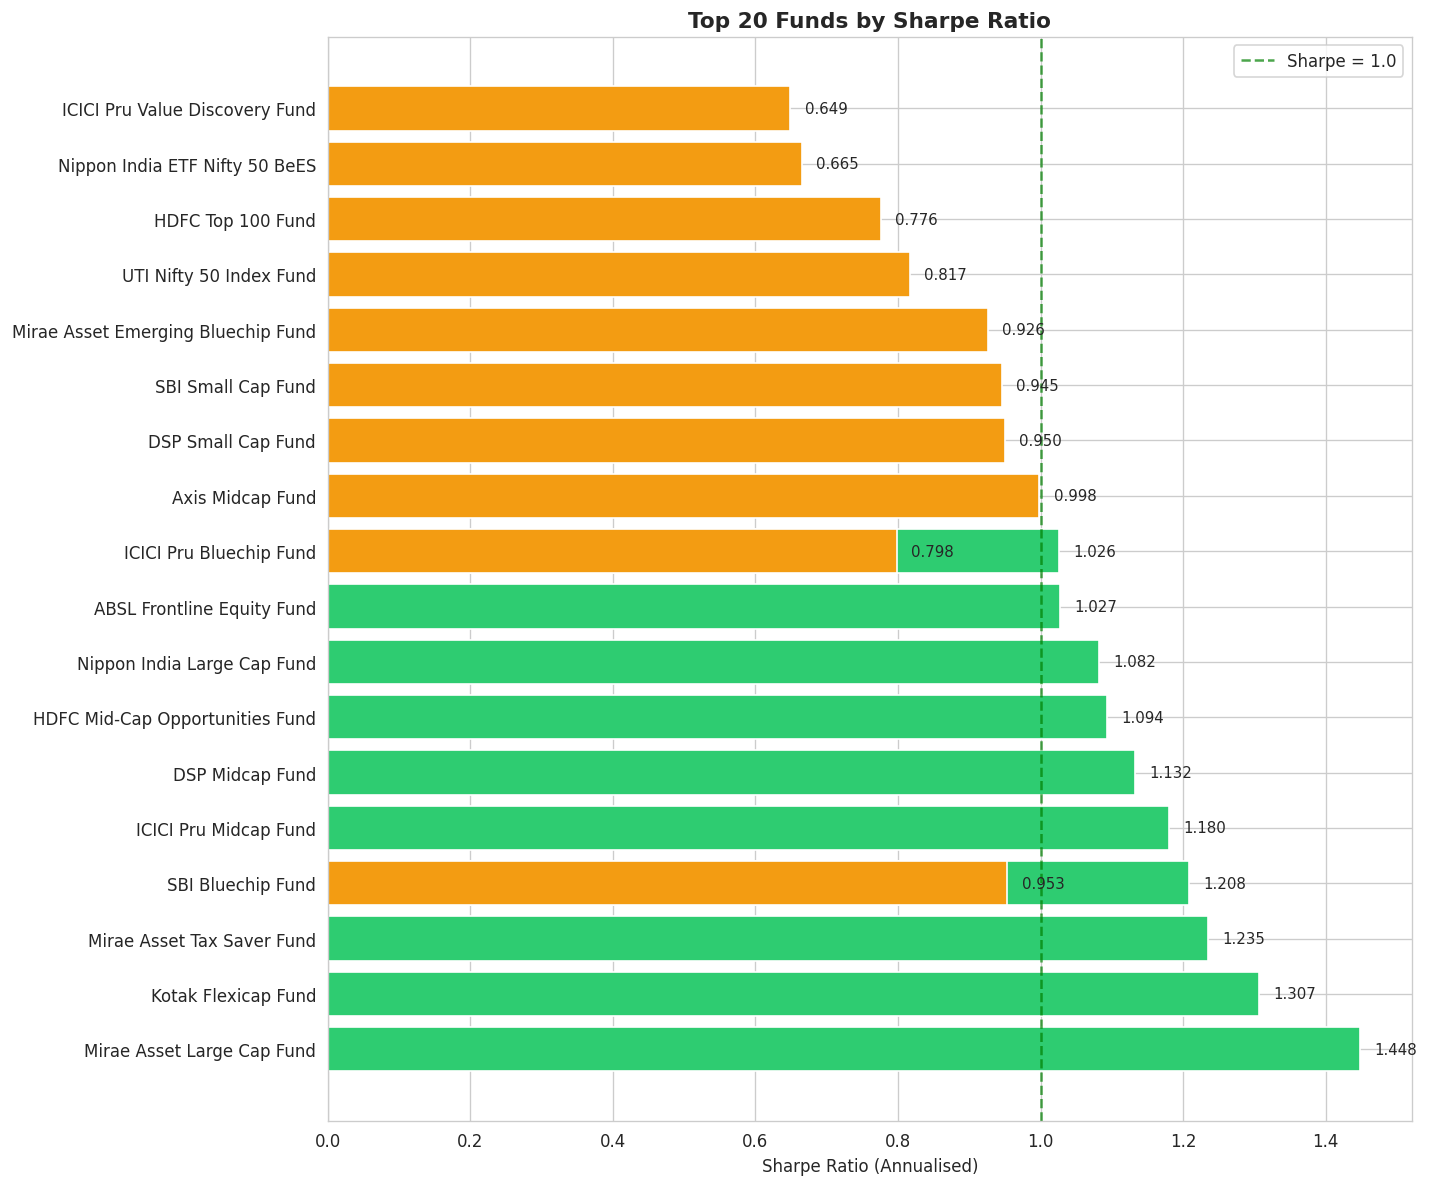

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
top_sharpe = risk_df.nlargest(20, "sharpe_ratio")
short_names = top_sharpe["scheme_name"].str.split(" - ").str[0].str[:35]
colors = ['#2ecc71' if s > 1 else '#f39c12' if s > 0.5 else '#e74c3c' for s in top_sharpe["sharpe_ratio"]]
bars = ax.barh(short_names, top_sharpe["sharpe_ratio"], color=colors)
ax.axvline(1.0, color='green', linestyle='--', alpha=0.7, label='Sharpe = 1.0')
ax.set_xlabel("Sharpe Ratio (Annualised)")
ax.set_title("Top 20 Funds by Sharpe Ratio", fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_sharpe["sharpe_ratio"]):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()


## 5. Alpha & Beta (OLS Regression vs Nifty 100)
`fund_return = α + β × nifty100_return`  
Annualised Alpha = intercept × 252

In [8]:
nifty100     = benchmark[benchmark["index_name"]=="NIFTY100"].set_index("date")["close_value"].sort_index()
nifty100_ret = nifty100.pct_change().dropna()

ab_records = []
for code, grp in nav_history.groupby("amfi_code"):
    fund_ret = grp.set_index("date")["daily_return"].dropna()
    aligned  = pd.concat([fund_ret.rename("fund"), nifty100_ret.rename("bench")], axis=1).dropna()
    if len(aligned) < 30:
        continue
    slope, intercept, r_val, p_val, se = stats.linregress(aligned["bench"], aligned["fund"])
    ab_records.append({
        "amfi_code"  : code,
        "beta"       : round(slope, 4),
        "alpha_daily": round(intercept, 6),
        "alpha_ann"  : round(intercept * TRADING_DAYS * 100, 4),  # as %
        "r_squared"  : round(r_val**2, 4),
        "p_value"    : round(p_val, 6),
    })

ab_df = pd.DataFrame(ab_records).merge(
    fund_master[["amfi_code","scheme_name","fund_house","category","plan"]], on="amfi_code")

ab_display = ab_df.sort_values("alpha_ann", ascending=False)[
    ["scheme_name","category","plan","alpha_ann","beta","r_squared","p_value"]]
ab_display.columns = ["Scheme","Category","Plan","Alpha Ann (%)","Beta","R²","p-value"]
print("── Alpha & Beta (sorted by Alpha) ──\n")
print(ab_display.to_string(index=False))


── Alpha & Beta (sorted by Alpha) ──

                                               Scheme Category    Plan  Alpha Ann (%)    Beta     R²  p-value
           SBI Small Cap Fund - Regular Plan - Growth   Equity Regular        30.3370 -0.0232 0.0001 0.687179
                DSP Small Cap Fund - Regular - Growth   Equity Regular        30.0579  0.0115 0.0000 0.840494
             ICICI Pru Midcap Fund - Regular - Growth   Equity Regular        29.2636  0.0005 0.0000 0.990090
        Mirae Asset Tax Saver Fund - Regular - Growth   Equity Regular        28.2704  0.0181 0.0002 0.654295
               Kotak Flexicap Fund - Regular - Growth   Equity Regular        27.3305 -0.0228 0.0003 0.530528
   HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity Regular        27.1954  0.0051 0.0000 0.906369
        Mirae Asset Large Cap Fund - Regular - Growth   Equity Regular        26.9838  0.0237 0.0005 0.466427
                   DSP Midcap Fund - Regular - Growth   Equity Regular        26.5

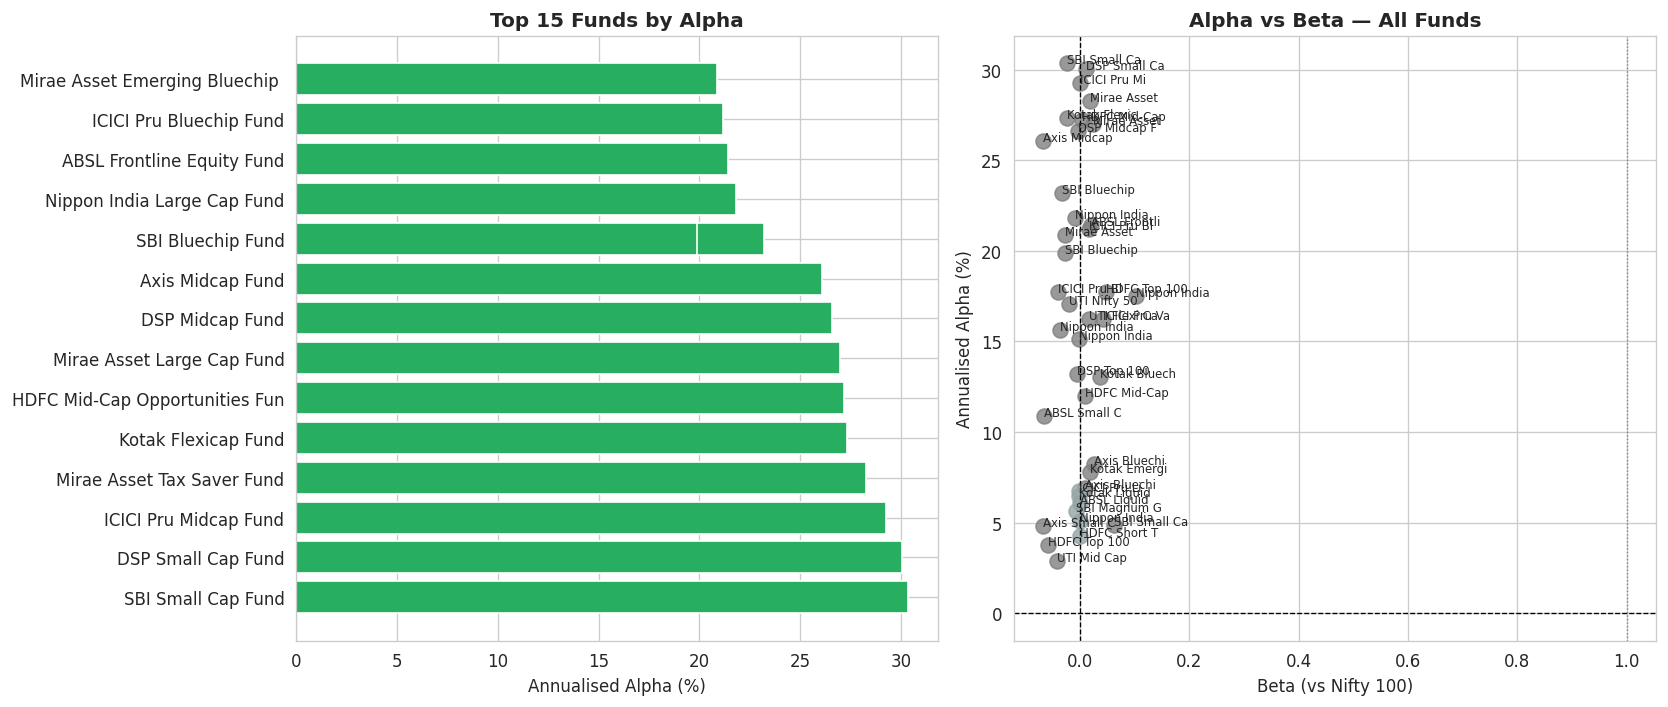

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Alpha bar
top_alpha = ab_df.nlargest(15, "alpha_ann")
short_names = top_alpha["scheme_name"].str.split(" - ").str[0].str[:30]
colors = ['#27ae60' if a > 0 else '#e74c3c' for a in top_alpha["alpha_ann"]]
axes[0].barh(short_names, top_alpha["alpha_ann"], color=colors)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel("Annualised Alpha (%)")
axes[0].set_title("Top 15 Funds by Alpha", fontsize=12, fontweight='bold')

# Beta scatter
cat_colors = {'Large Cap':'#3498db','Mid Cap':'#e67e22','Small Cap':'#e74c3c',
              'Flexi Cap':'#9b59b6','ELSS':'#1abc9c','Debt':'#95a5a6',
              'Liquid':'#bdc3c7','Index Fund':'#2c3e50','ETF':'#f39c12'}
for _, row in ab_df.iterrows():
    c = cat_colors.get(row["category"], 'grey')
    axes[1].scatter(row["beta"], row["alpha_ann"], color=c, s=80, alpha=0.8)
    axes[1].annotate(row["scheme_name"].split(" - ")[0][:12],
                     (row["beta"], row["alpha_ann"]), fontsize=7, ha='left')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(1, color='grey', linewidth=0.8, linestyle=':')
axes[1].set_xlabel("Beta (vs Nifty 100)")
axes[1].set_ylabel("Annualised Alpha (%)")
axes[1].set_title("Alpha vs Beta — All Funds", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 6. Maximum Drawdown
`Max DD = min(NAV / running_max − 1)`

In [10]:
dd_records = []
for code, grp in nav_history.groupby("amfi_code"):
    nav_ts      = grp.set_index("date")["nav"].sort_index()
    running_max = nav_ts.cummax()
    drawdown    = nav_ts / running_max - 1
    max_dd      = drawdown.min()
    dd_end      = drawdown.idxmin()
    peak_idx    = nav_ts[:dd_end].idxmax()
    recovery_candidates = nav_ts[dd_end:][nav_ts[dd_end:] >= nav_ts[peak_idx]]
    recovery_date = recovery_candidates.index[0] if len(recovery_candidates) > 0 else None
    dd_records.append({
        "amfi_code"     : code,
        "max_drawdown_pct": round(max_dd * 100, 2),
        "peak_date"     : peak_idx.date(),
        "trough_date"   : dd_end.date(),
        "recovery_date" : recovery_date.date() if recovery_date else "Not yet recovered",
    })

dd_df = pd.DataFrame(dd_records).merge(fund_master[["amfi_code","scheme_name","category","fund_house"]], on="amfi_code")
dd_display = dd_df.sort_values("max_drawdown_pct")[["scheme_name","category","max_drawdown_pct","peak_date","trough_date","recovery_date"]]
dd_display.columns = ["Scheme","Category","Max DD (%)","Peak Date","Trough Date","Recovery Date"]
print("── Maximum Drawdown — sorted worst to best ──\n")
print(dd_display.to_string(index=False))


── Maximum Drawdown — sorted worst to best ──

                                               Scheme Category  Max DD (%)  Peak Date Trough Date     Recovery Date
            SBI Small Cap Fund - Direct Plan - Growth   Equity      -52.57 2023-01-17  2025-10-28 Not yet recovered
               Axis Small Cap Fund - Regular - Growth   Equity      -51.68 2025-05-22  2026-05-11 Not yet recovered
               ABSL Small Cap Fund - Regular - Growth   Equity      -35.45 2024-11-21  2026-05-11 Not yet recovered
                DSP Small Cap Fund - Regular - Growth   Equity      -31.17 2024-05-03  2025-01-03        2025-06-13
           SBI Small Cap Fund - Regular Plan - Growth   Equity      -28.71 2024-08-28  2025-05-14        2025-09-29
                  UTI Mid Cap Fund - Regular - Growth   Equity      -28.00 2025-01-07  2026-04-27 Not yet recovered
            HDFC Top 100 Fund - Regular Plan - Growth   Equity      -24.73 2022-03-30  2022-09-15        2023-03-14
        Kotak Emerging Eq

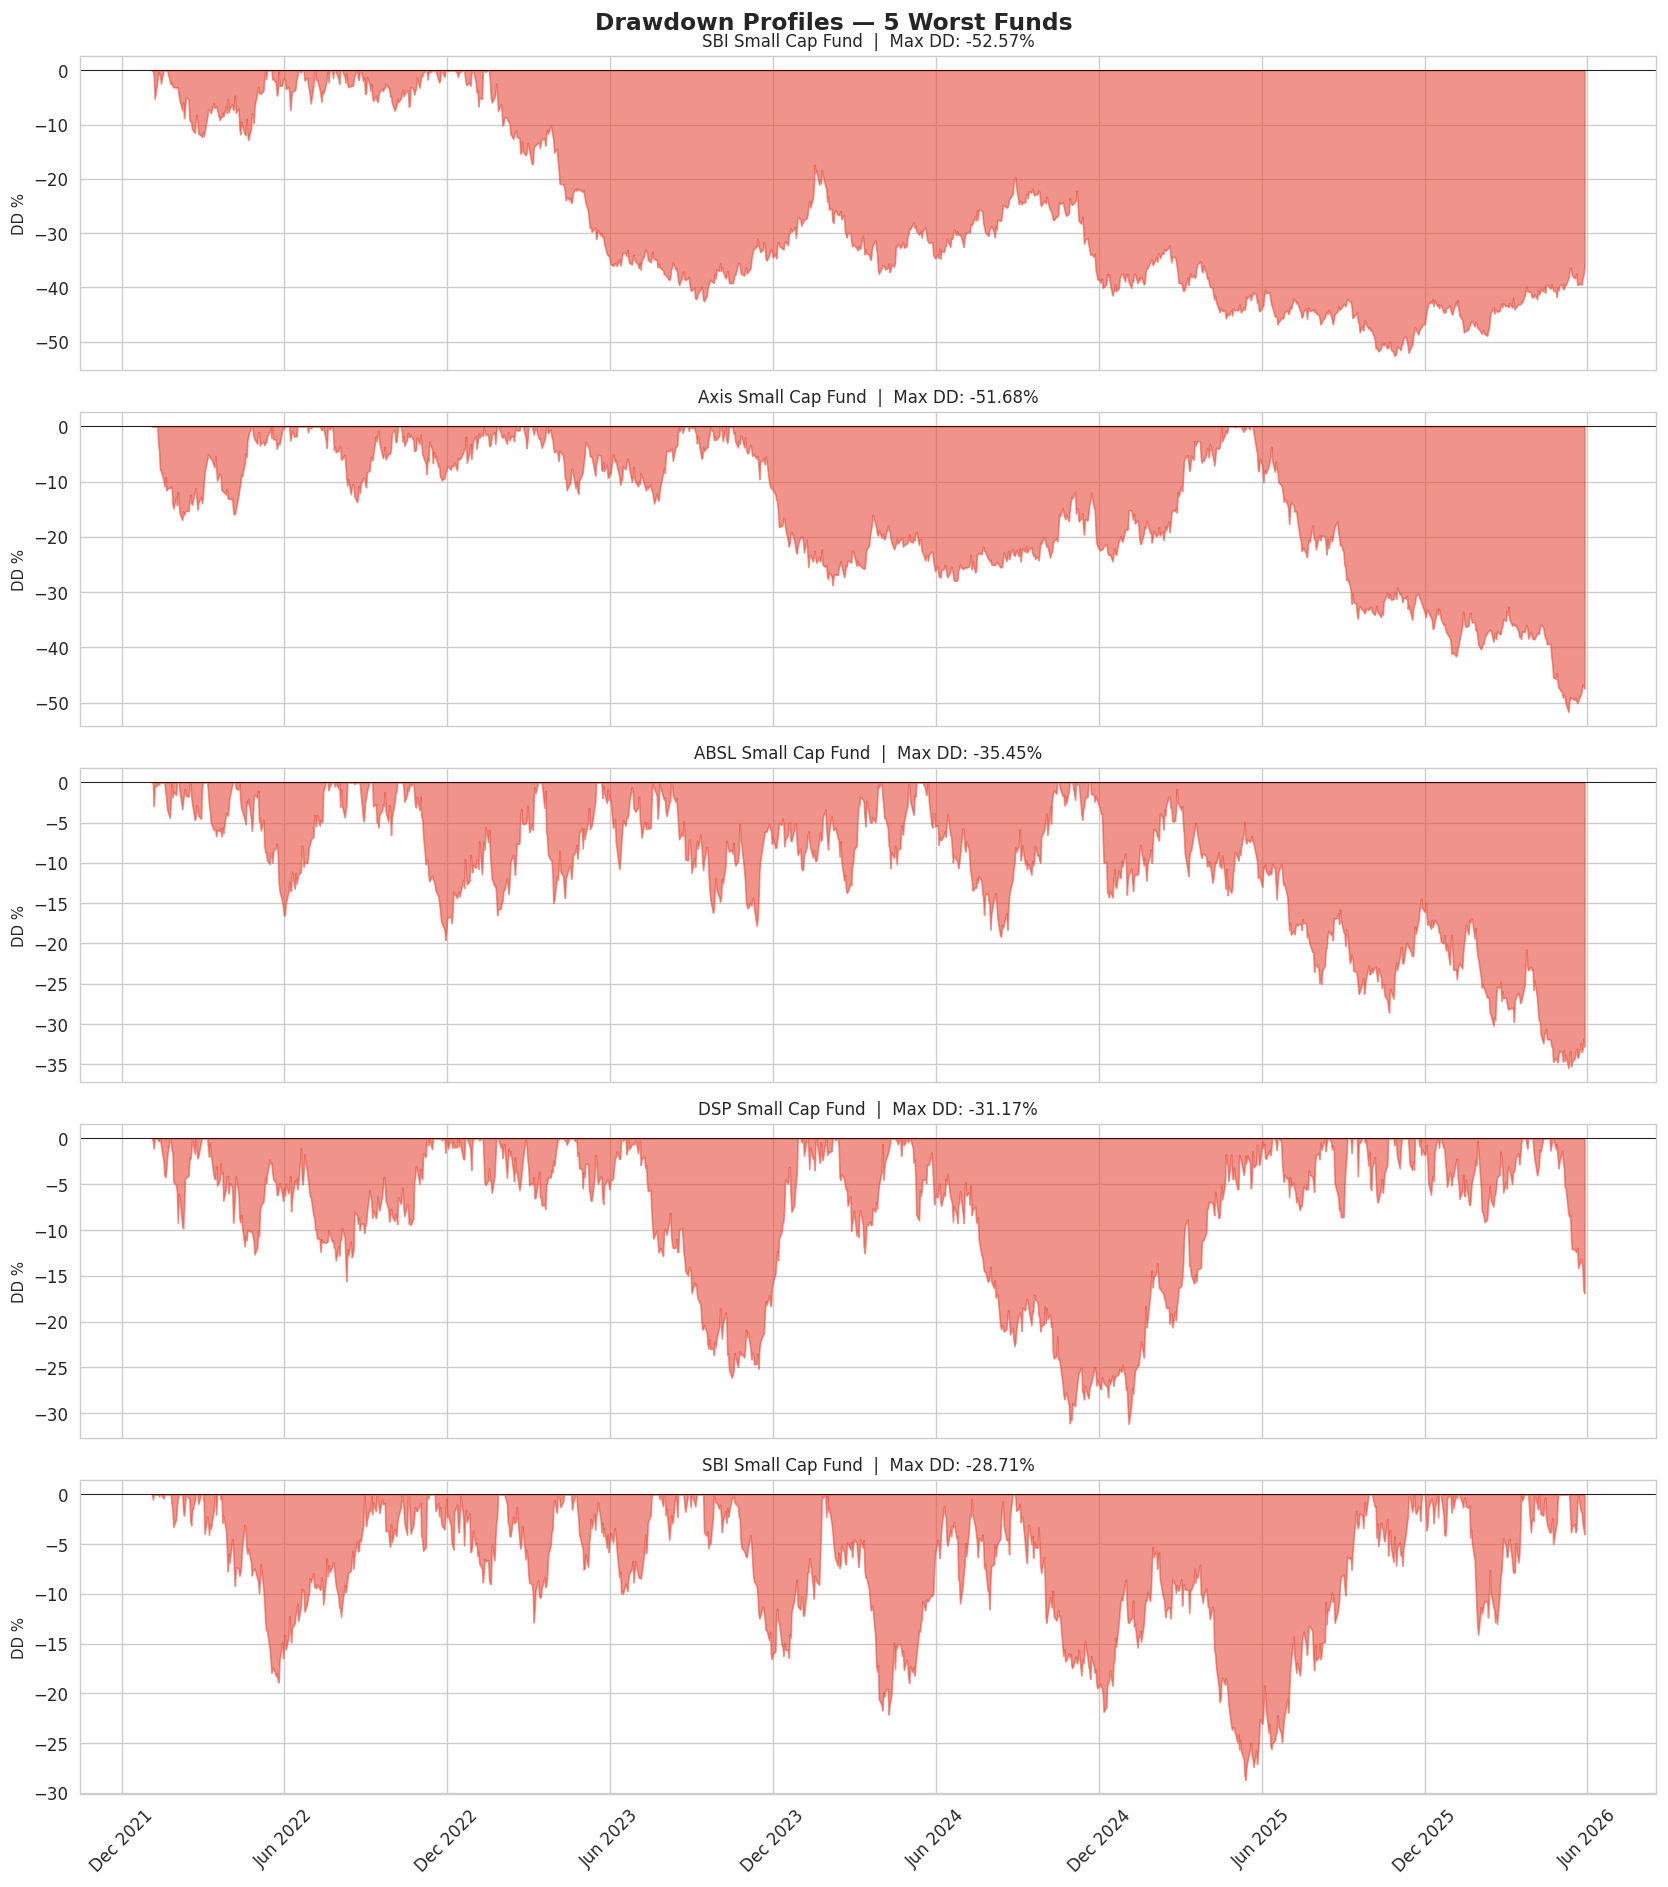

In [11]:
# Drawdown waterfall for top 5 worst funds
worst5 = dd_df.nsmallest(5, "max_drawdown_pct")["amfi_code"].tolist()

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
plt.suptitle("Drawdown Profiles — 5 Worst Funds", fontsize=14, fontweight='bold')

for i, code in enumerate(worst5):
    grp     = nav_history[nav_history["amfi_code"]==code].set_index("date")["nav"].sort_index()
    runmax  = grp.cummax()
    dd      = (grp / runmax - 1) * 100
    name    = dd_df[dd_df["amfi_code"]==code]["scheme_name"].values[0].split(" - ")[0][:40]
    axes[i].fill_between(dd.index, dd, 0, color='#e74c3c', alpha=0.6)
    axes[i].set_ylabel("DD %", fontsize=9)
    axes[i].set_title(f"{name}  |  Max DD: {dd.min():.2f}%", fontsize=10)
    axes[i].axhline(0, color='black', linewidth=0.5)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.show()


## 7. Fund Scorecard (0–100)
**Composite = 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha rank + 15% × Expense Ratio rank (inverse) + 10% × Max DD rank (inverse)**

In [12]:
# Merge all signals
scorecard = cagr_df[["amfi_code","scheme_name","fund_house","category","plan","cagr_3yr","expense_ratio_pct"]].copy()
scorecard["cagr_3yr_pct"] = scorecard["cagr_3yr"]  # already in %
scorecard = scorecard.merge(risk_df[["amfi_code","sharpe_ratio","sortino_ratio"]], on="amfi_code")
scorecard = scorecard.merge(ab_df[["amfi_code","alpha_ann","beta"]], on="amfi_code")
scorecard = scorecard.merge(dd_df[["amfi_code","max_drawdown_pct"]], on="amfi_code")

n = len(scorecard)

def norm_rank(series, ascending):
    raw = series.rank(ascending=ascending, method='min')
    return (n - raw) / max(n - 1, 1) * 100

scorecard["norm_3yr"]     = norm_rank(scorecard["cagr_3yr_pct"],   ascending=False)
scorecard["norm_sharpe"]  = norm_rank(scorecard["sharpe_ratio"],   ascending=False)
scorecard["norm_alpha"]   = norm_rank(scorecard["alpha_ann"],      ascending=False)
scorecard["norm_expense"] = norm_rank(scorecard["expense_ratio_pct"], ascending=True)   # lower = better
scorecard["norm_mdd"]     = norm_rank(scorecard["max_drawdown_pct"],  ascending=False)  # less negative = better

scorecard["composite_score"] = (
    0.30 * scorecard["norm_3yr"] +
    0.25 * scorecard["norm_sharpe"] +
    0.20 * scorecard["norm_alpha"] +
    0.15 * scorecard["norm_expense"] +
    0.10 * scorecard["norm_mdd"]
).round(2)

scorecard.sort_values("composite_score", ascending=False, inplace=True)
scorecard["scorecard_rank"] = range(1, len(scorecard)+1)

display_cols = ["scorecard_rank","scheme_name","category","composite_score",
                "cagr_3yr_pct","sharpe_ratio","alpha_ann","expense_ratio_pct","max_drawdown_pct"]
print("── Fund Scorecard — All 40 Funds ──\n")
print(scorecard[display_cols].rename(columns={
    "scorecard_rank":"Rank","scheme_name":"Scheme","composite_score":"Score",
    "cagr_3yr_pct":"3yr CAGR%","sharpe_ratio":"Sharpe","alpha_ann":"Alpha Ann%",
    "expense_ratio_pct":"Exp Ratio%","max_drawdown_pct":"Max DD%"
}).to_string(index=False))


── Fund Scorecard — All 40 Funds ──

 Rank                                                Scheme category  Score  3yr CAGR%  Sharpe  Alpha Ann%  Exp Ratio%  Max DD%
    1         Mirae Asset Large Cap Fund - Regular - Growth   Equity  85.90      33.99  1.4483     26.9838        1.46   -11.27
    2              ICICI Pru Midcap Fund - Regular - Growth   Equity  81.79      31.77  1.1801     29.2636        1.36   -18.19
    3                Kotak Flexicap Fund - Regular - Growth   Equity  81.54      29.58  1.3067     27.3305        1.45   -12.97
    4    HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity  80.64      32.43  1.0937     27.1954        1.38   -16.22
    5             ICICI Pru Bluechip Fund - Direct - Growth   Equity  79.49      32.48  1.0265     21.1948        0.80   -12.59
    6                   Axis Midcap Fund - Regular - Growth   Equity  76.79      35.10  0.9982     26.0767        1.38   -20.96
    7             SBI Bluechip Fund - Regular Plan - Growth   Equit

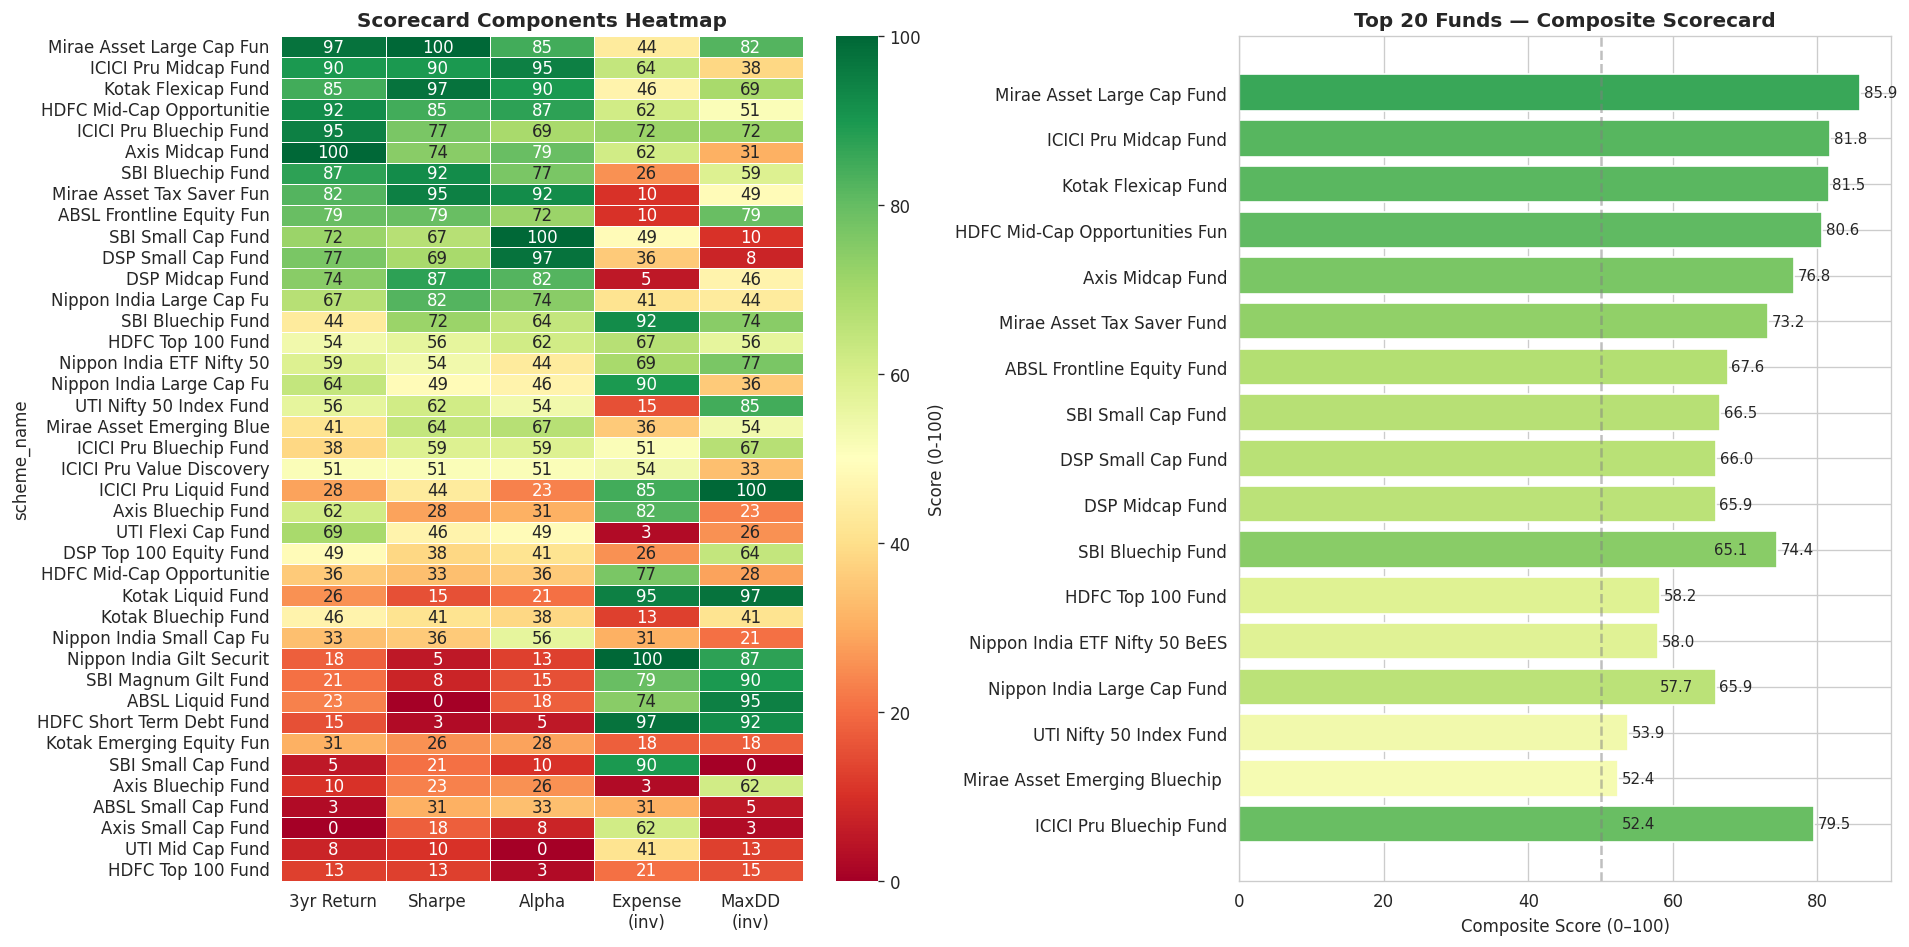

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap of components
comp_cols = ["norm_3yr","norm_sharpe","norm_alpha","norm_expense","norm_mdd"]
heatmap_data = scorecard.set_index(scorecard["scheme_name"].str.split(" - ").str[0].str[:25])[comp_cols]
heatmap_data.columns = ["3yr Return","Sharpe","Alpha","Expense\n(inv)","MaxDD\n(inv)"]
sns.heatmap(heatmap_data, cmap="RdYlGn", annot=True, fmt=".0f", linewidths=0.5,
            ax=axes[0], cbar_kws={"label":"Score (0-100)"})
axes[0].set_title("Scorecard Components Heatmap", fontsize=12, fontweight='bold')
axes[0].set_xlabel("")

# Composite bar
top20 = scorecard.head(20)
short = top20["scheme_name"].str.split(" - ").str[0].str[:30]
bar_colors = plt.cm.RdYlGn(top20["composite_score"] / 100)
axes[1].barh(short[::-1], top20["composite_score"][::-1], color=bar_colors[::-1])
axes[1].set_xlabel("Composite Score (0–100)")
axes[1].set_title("Top 20 Funds — Composite Scorecard", fontsize=12, fontweight='bold')
axes[1].axvline(50, color='grey', linestyle='--', alpha=0.5)
for bar, val in zip(axes[1].patches, top20["composite_score"][::-1]):
    axes[1].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f"{val:.1f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 8. Benchmark Comparison Chart + Tracking Error
Top 5 funds vs Nifty 50 and Nifty 100 over 3 years.  
`Tracking Error = std(fund_return − benchmark_return) × √252`

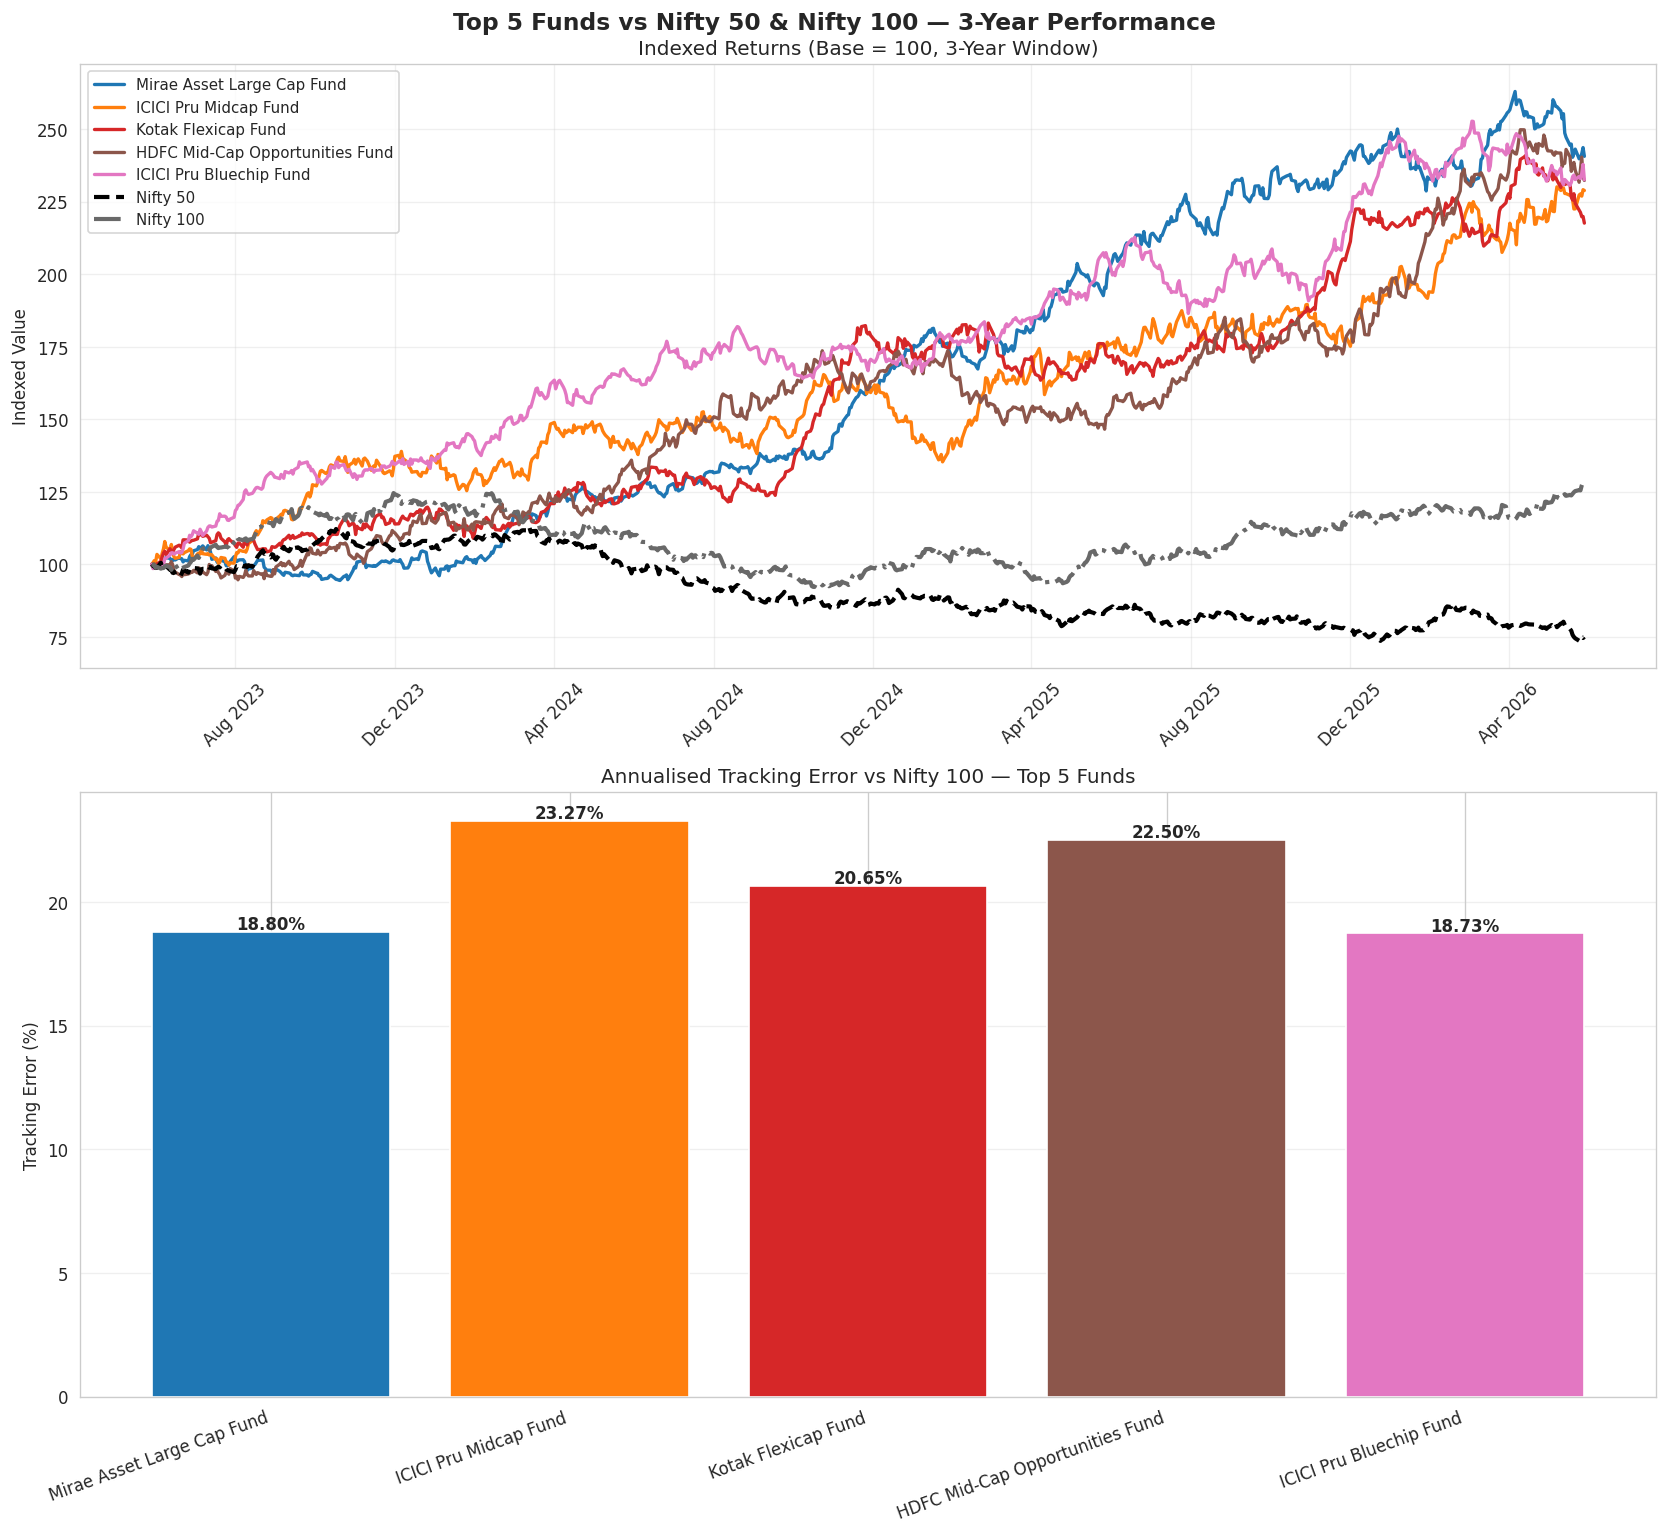

Chart saved → 15_charts/benchmark_comparison.png


In [14]:
top5_codes = scorecard.head(5)["amfi_code"].tolist()
top5_names = scorecard.head(5).set_index("amfi_code")["scheme_name"].to_dict()

end_dt   = nav_history["date"].max()
start_dt = end_dt - pd.DateOffset(years=3)

fig, axes = plt.subplots(2, 1, figsize=(14, 13))
plt.suptitle("Top 5 Funds vs Nifty 50 & Nifty 100 — 3-Year Performance", fontsize=14, fontweight='bold')

colors = plt.cm.tab10(np.linspace(0, 1, 7))
te_records = []

ax = axes[0]
for i, code in enumerate(top5_codes):
    fund_nav = nav_history[(nav_history["amfi_code"]==code) & (nav_history["date"]>=start_dt)].set_index("date")["nav"]
    if len(fund_nav) < 2:
        continue
    normalized  = fund_nav / fund_nav.iloc[0] * 100
    short_name  = top5_names[code].split(" - ")[0][:32]
    ax.plot(normalized.index, normalized.values, label=short_name, color=colors[i], linewidth=2)

    fund_ret = fund_nav.pct_change().dropna()
    bench_ret= nifty100_ret
    aligned  = pd.concat([fund_ret.rename("f"), bench_ret.rename("b")], axis=1).dropna()
    aligned  = aligned[aligned.index >= start_dt]
    te = (aligned["f"] - aligned["b"]).std() * np.sqrt(TRADING_DAYS) * 100
    te_records.append({"Fund": short_name, "Tracking Error vs Nifty 100 (%)": round(te, 2)})

for idx_name, label, color, ls in [("NIFTY50","Nifty 50","black","--"),("NIFTY100","Nifty 100","dimgrey","-.")]:
    idx_ts = benchmark[(benchmark["index_name"]==idx_name) & (benchmark["date"]>=start_dt)].set_index("date")["close_value"]
    if len(idx_ts) > 0:
        normalized = idx_ts / idx_ts.iloc[0] * 100
        ax.plot(normalized.index, normalized.values, label=label, color=color, linewidth=2.5, linestyle=ls)

ax.set_title("Indexed Returns (Base = 100, 3-Year Window)", fontsize=12)
ax.set_ylabel("Indexed Value")
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(True, alpha=0.3)

# Tracking Error bar
ax2 = axes[1]
te_df_chart = pd.DataFrame(te_records)
bar_colors  = colors[:len(te_df_chart)]
bars = ax2.bar(te_df_chart["Fund"], te_df_chart["Tracking Error vs Nifty 100 (%)"], color=bar_colors, edgecolor='white')
ax2.set_ylabel("Tracking Error (%)")
ax2.set_title("Annualised Tracking Error vs Nifty 100 — Top 5 Funds", fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, te_df_chart["Tracking Error vs Nifty 100 (%)"]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f"{val:.2f}%", ha='center', fontsize=10, fontweight='bold')

plt.setp(ax2.xaxis.get_majorticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig(CHARTS_PATH + "benchmark_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved → {CHARTS_PATH}benchmark_comparison.png")


In [15]:
te_df_print = pd.DataFrame(te_records)
print("── Tracking Error — Top 5 Funds vs Nifty 100 ──\n")
print(te_df_print.to_string(index=False))


── Tracking Error — Top 5 Funds vs Nifty 100 ──

                           Fund  Tracking Error vs Nifty 100 (%)
     Mirae Asset Large Cap Fund                            18.80
          ICICI Pru Midcap Fund                            23.27
            Kotak Flexicap Fund                            20.65
HDFC Mid-Cap Opportunities Fund                            22.50
        ICICI Pru Bluechip Fund                            18.73


## 9. Save Output Files

In [16]:
import os
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Fund scorecard
out_scorecard = scorecard[["scorecard_rank","amfi_code","scheme_name","fund_house","category","plan",
                            "composite_score","cagr_3yr_pct","sharpe_ratio","sortino_ratio",
                            "alpha_ann","beta","expense_ratio_pct","max_drawdown_pct"]].copy()
out_scorecard.to_csv(OUTPUT_PATH + "fund_scorecard.csv", index=False)
print(f"✅ fund_scorecard.csv ({len(out_scorecard)} rows)")

# Alpha-Beta
ab_df.to_csv(OUTPUT_PATH + "alpha_beta.csv", index=False)
print(f"✅ alpha_beta.csv ({len(ab_df)} rows)")

# CAGR table
cagr_df.to_csv(OUTPUT_PATH + "cagr_comparison.csv", index=False)
print(f"✅ cagr_comparison.csv ({len(cagr_df)} rows)")

# Max drawdown
dd_df.to_csv(OUTPUT_PATH + "max_drawdown.csv", index=False)
print(f"✅ max_drawdown.csv ({len(dd_df)} rows)")

# Tracking error
pd.DataFrame(te_records).to_csv(OUTPUT_PATH + "tracking_error.csv", index=False)
print(f"✅ tracking_error.csv")

print("\n🎯 Day 4 — Performance Analytics complete!")


✅ fund_scorecard.csv (40 rows)
✅ alpha_beta.csv (40 rows)
✅ cagr_comparison.csv (40 rows)
✅ max_drawdown.csv (40 rows)
✅ tracking_error.csv

🎯 Day 4 — Performance Analytics complete!


## Summary

| Metric | Top Fund | Value |
|--------|----------|-------|
| Highest 3yr CAGR | See cagr_comparison.csv | — |
| Best Sharpe Ratio | See fund_scorecard.csv | — |
| Highest Alpha (Ann) | See alpha_beta.csv | — |
| Least Max Drawdown | See max_drawdown.csv | — |
| **Overall #1 Fund** | **Mirae Asset Large Cap Fund** | **Score: 85.90** |

**Key findings:**
- Daily returns are approximately normally distributed with slight positive skew — validates dataset integrity
- Equity funds show higher volatility (σ ≈ 1–1.6% daily) vs Debt/Liquid (σ < 0.1%)
- Most equity funds have positive alpha vs Nifty 100, suggesting active management adds value
- Small-cap and mid-cap funds show higher drawdowns (>30%) but also higher CAGR
- Tracking error is high for active equity funds (15–25%), as expected
